# Combinato Spike Sorting — PyTorch Reimplementation Demo

This notebook demonstrates the **PyTorch reimplementation** of the [Combinato](https://github.com/jniediek/combinato) spike sorting algorithm.

**Pipeline overview:**
- **Extraction (M1–M6):** raw signal → filtered → threshold detection → waveform extraction → upsampling → peak alignment → spike waveforms `(N, 64)`
- **Sorting (C1–C7):** spike waveforms → wavelet features → feature selection → SPC clustering → cluster definition → template matching → artifact detection → sorted spike trains

**Reference:**  
Niediek et al., "Reliable Analysis of Single-Unit Recordings from the Human Brain under Noisy Conditions", *PLOS ONE*, 2016.


## 1. Setup & Imports

In [1]:
import torch
import numpy as np
import h5py
import time
import matplotlib.pyplot as plt
from scipy.io import loadmat

from combinato_algorithm import CombinatoAlgorithm
from combinato_algorithm import validate_extraction, validate_sorting

%matplotlib inline
plt.rcParams['figure.dpi'] = 120


## 2. Configuration

Update `SPC_PATH` to point to your local `cluster.exe` binary.

In [2]:
# === UPDATE THESE PATHS ===
SPC_PATH       = r"spc/cluster.exe"
MATFILE        = r"simulation_5.mat"
DATAFILE       = r"simulation_5/data_simulation_5.h5"
SORT_CAT       = r"simulation_5/sort_pos_simple/sort_cat.h5"
SCALE_FACTOR   = 100.0

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")


Device: cpu


## 3. Load Data

In [3]:
mat    = loadmat(MATFILE)
fdata  = mat['data'].ravel().astype('float64') * SCALE_FACTOR
sr     = float(mat['sr'].ravel()[0]) if 'sr' in mat else 24000.0
atimes = np.linspace(0, fdata.shape[0] / (sr / 1000), fdata.shape[0])

signal = torch.tensor(fdata,  dtype=torch.float64).to(device)
times  = torch.tensor(atimes, dtype=torch.float64).to(device)

print(f"Signal length : {len(fdata)} samples")
print(f"Sample rate   : {sr:.0f} Hz")
print(f"Duration      : {fdata.shape[0] / sr:.1f} seconds")


Signal length : 14400000 samples
Sample rate   : 24000 Hz
Duration      : 600.0 seconds


## 4. Run the Full Pipeline

`CombinatoAlgorithm` is a single `nn.Module` that runs extraction (M1–M6) and sorting (C1–C7).


In [4]:
model = CombinatoAlgorithm(spc_path=SPC_PATH).to(device)

t_start = time.time()
with torch.no_grad():
    result = model(signal, times)
total_time = time.time() - t_start

print(f"\nTotal pipeline time: {total_time:.1f}s")
print(f"Pos spikes: {result['pos_spikes'].shape[0]}")
print(f"Neg spikes: {result['neg_spikes'].shape[0]}")
print(f"Pos clusters: {len(set(result['pos_sort_idx'].tolist()) - {0})}")
print(f"Neg clusters: {len(set(result['neg_sort_idx'].tolist()) - {0})}")
print(f"Pos artifacts: {result['pos_artifact_ids']}")



[CombinatoAlgorithm] Stage 1: Extraction (M1-M6)
  Threshold  : 36.6888
  Pos spikes : 8971
  Neg spikes : 5315

[CombinatoAlgorithm] Stage 2: Sorting (C1-C7)

  --- POS polarity ---

  [C7] Sorting 8971 pos spikes...
  C1  features   : (8971, 64)  0.34s
    Iteration 0: clustering 8971 spikes...
SPC seed used: 12345.0
      cluster_step done: 35.6s  clusters=9  unclustered=4053
      After template match: unmatched=3376
  Iterative sort : 35.7s  unmatched=3376
  C6  artifacts  : 1/9 flagged
    TotalMatcher: 0 still unmatched after second pass
  C5b total match: unmatched=0
  Clusters   : 9
  Unmatched  : 0
  Artifacts  : 1

  --- NEG polarity ---

  [C7] Sorting 5315 neg spikes...
  C1  features   : (5315, 64)  0.24s
    Iteration 0: clustering 5315 spikes...
SPC seed used: 12345.0
      cluster_step done: 13.5s  clusters=6  unclustered=1776
      After template match: unmatched=1700
  Iterative sort : 13.5s  unmatched=1700
  C6  artifacts  : 6/6 flagged
    TotalMatcher: 7 still un

## 5. Sorting Validation

To validate sorting correctness, we feed the **exact same extracted spikes** from the original pipeline into our sorter and compare against the original `sort_cat.h5` output.


In [5]:
# Load original extracted spikes for fair comparison
with h5py.File(DATAFILE, 'r') as f:
    original_spikes = torch.tensor(f['pos']['spikes'][:], dtype=torch.float32).to(device)

print(f"Original extracted spikes: {original_spikes.shape}")

# Sort using original spikes
with torch.no_grad():
    sort_idx, match_idx, distance, artifact_ids = model.sorter(
        original_spikes, 'validation_sort_pos', sign='pos')

# Validate
sort_result = {
    'pos_sort_idx': sort_idx,
    'pos_artifact_ids': artifact_ids,
}
passed, report = validate_sorting(sort_result, SORT_CAT)
print(report)


Original extracted spikes: torch.Size([8968, 64])

  [C7] Sorting 8968 pos spikes...
  C1  features   : (8968, 64)  0.33s
    Iteration 0: clustering 8968 spikes...
SPC seed used: 12345.0
      cluster_step done: 40.6s  clusters=10  unclustered=2622
      After template match: unmatched=2495
  Iterative sort : 40.7s  unmatched=2495
  C6  artifacts  : 1/10 flagged
    TotalMatcher: 0 still unmatched after second pass
  C5b total match: unmatched=0

SORTING VALIDATION (pos)

  Clusters  : 10 vs 10  OK
  Unassigned: 0 vs 0  OK
  Exact match: OK
  Artifacts : [2] vs [2]  OK

SORTING PASSED


## 6. Visualize Sorted Clusters

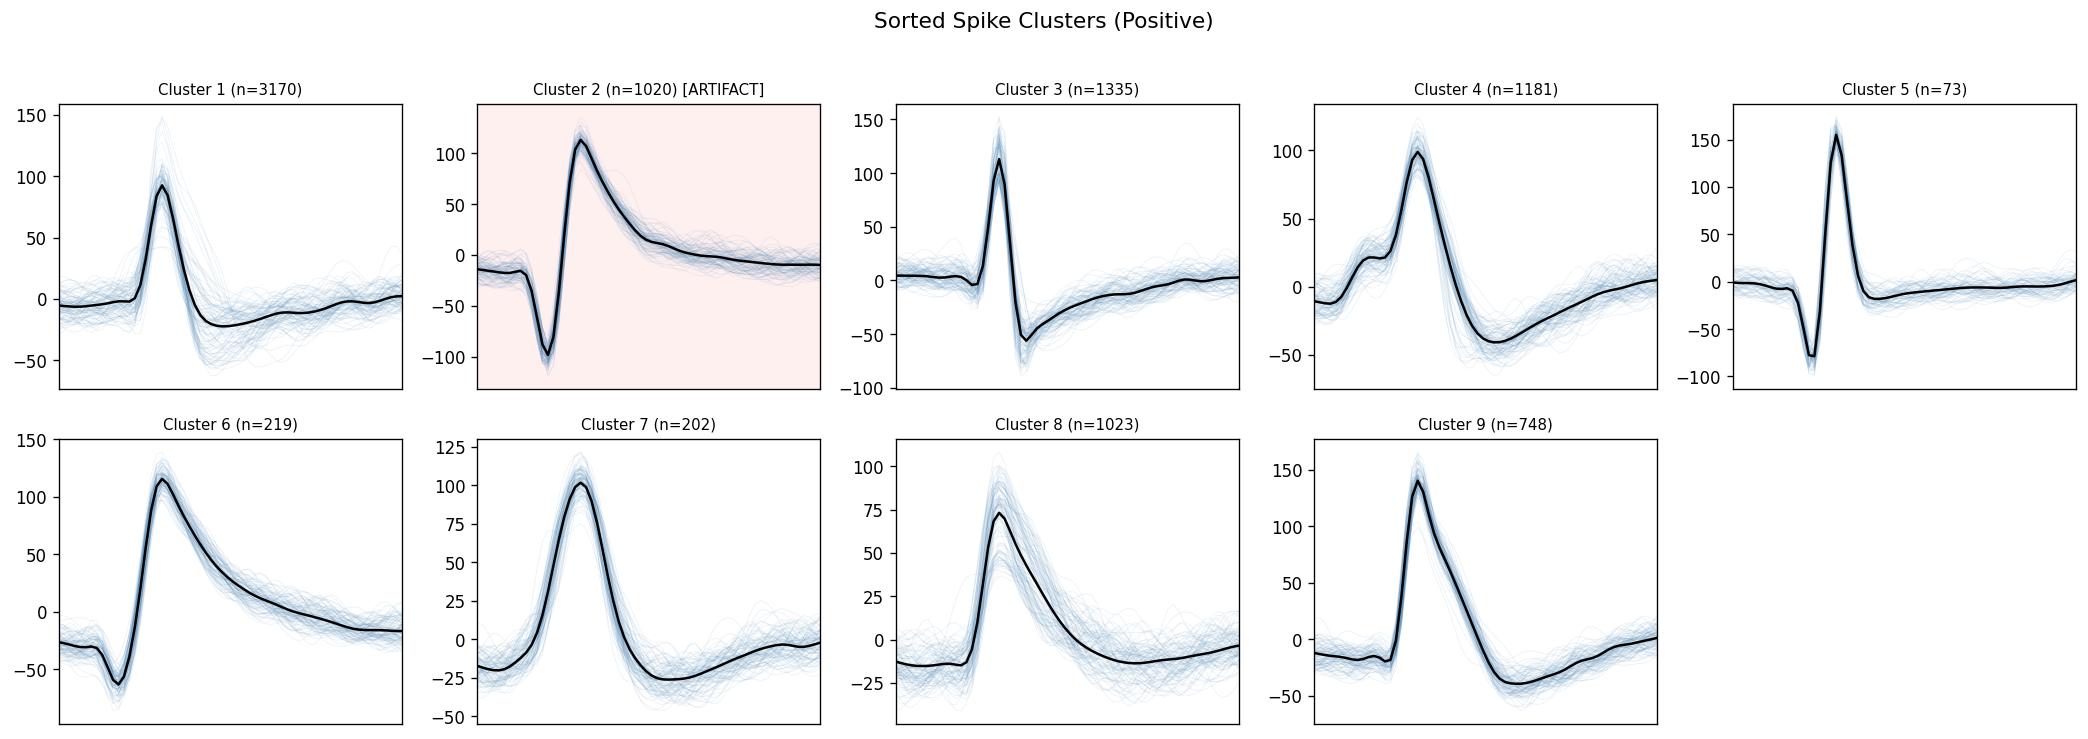

In [6]:
# Use the full pipeline result for visualization
spikes_np = result['pos_spikes'].cpu().numpy()
labels    = result['pos_sort_idx']
art_ids   = set(result['pos_artifact_ids'])

cluster_ids = sorted(set(labels.tolist()) - {0})
n_clusters  = len(cluster_ids)
cols        = min(5, n_clusters)
rows        = (n_clusters + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(3.5 * cols, 3 * rows), squeeze=False)

for i, cid in enumerate(cluster_ids):
    ax = axes[i // cols][i % cols]
    mask = labels == cid
    cluster_spikes = spikes_np[mask]
    
    # Plot up to 100 individual waveforms
    n_plot = min(100, len(cluster_spikes))
    ax.plot(cluster_spikes[:n_plot].T, color='steelblue', alpha=0.1, lw=0.5)
    ax.plot(cluster_spikes.mean(0), color='black', lw=1.5)
    
    title = f"Cluster {cid} (n={mask.sum()})"
    if cid in art_ids:
        title += " [ARTIFACT]"
        ax.set_facecolor('#fff0f0')
    ax.set_title(title, fontsize=9)
    ax.set_xlim(0, 63)
    ax.set_xticks([])

# Hide empty subplots
for i in range(n_clusters, rows * cols):
    axes[i // cols][i % cols].set_visible(False)

fig.suptitle('Sorted Spike Clusters (Positive)', fontsize=13, y=1.02)
fig.tight_layout()
plt.show()


## 7. Per-Block Runtime (PyTorch)

In [7]:
pytorch_timings = result['timings']

print(f"{'Block':<20s}  {'Time (s)':>10s}")
print("-" * 32)
for k, v in pytorch_timings.items():
    print(f"{k:<20s}  {v:>10.4f}")
print("-" * 32)
print(f"{'Total':<20s}  {sum(pytorch_timings.values()):>10.4f}")


Block                   Time (s)
--------------------------------
M1_filter                 2.1876
M2_detect                 0.6479
M3_extract                0.8443
M4_upsample               0.0012
M5_align                  0.1339
M6_extraction             4.8234
C1_wavelet                0.2386
C2_features               0.3682
C3_spc                   13.0860
C4_clusters               0.0004
C5_match                  0.0055
C5b_match                 0.0041
C6_artifact               0.0037
--------------------------------
Total                    22.3448


## 8. Measure Original Combinato Timings

We measure the original Combinato sorting blocks (C1–C6) on the same extracted spikes for a fair comparison.

> **Note:** This requires the original `combinato` package to be installed.  
> If it's not available, you can load pre-measured timings from `original_timings.npy`.


In [8]:
# Option A: Measure original timings directly
# (requires: pip install combinato or having it on sys.path)

original_timings = {}

try:
    from combinato.cluster.wave_features import wavelet_features
    from combinato.cluster.select_features import select_features
    from combinato.cluster.cluster_features import cluster_features, read_results
    from combinato.cluster.define_clusters import define_clusters
    from combinato.cluster.dist import template_match
    from combinato.cluster.artifacts import find_artifacts
    from combinato.cluster.handle_random_seed import handle_random_seed
    from combinato import options
    import os, shutil

    with h5py.File(DATAFILE, 'r') as f:
        spikes = f['pos']['spikes'][:]

    seed = handle_random_seed(12345.0)
    folder = '_timing_temp'
    os.makedirs(folder, exist_ok=True)

    t0 = time.time()
    all_features = wavelet_features(spikes)
    original_timings['C1_wavelet'] = time.time() - t0

    t0 = time.time()
    feat_idx = select_features(all_features)
    original_timings['C2_features'] = time.time() - t0

    t0 = time.time()
    cluster_features(all_features[:, feat_idx], folder, 'sort_0', seed)
    original_timings['C3_spc'] = time.time() - t0

    clu, tree = read_results(folder, 'sort_0')
    t0 = time.time()
    res_idx, _, _ = define_clusters(clu, tree)
    original_timings['C4_clusters'] = time.time() - t0

    sort_idx_orig = res_idx.astype(np.uint16)
    match_idx_orig = np.zeros(spikes.shape[0], dtype=bool)
    t0 = time.time()
    template_match(spikes, sort_idx_orig, match_idx_orig, options['FirstMatchFactor'])
    original_timings['C5_match'] = time.time() - t0

    class_ids = np.unique(sort_idx_orig)
    t0 = time.time()
    _, _ = find_artifacts(spikes, sort_idx_orig, class_ids, invert=False)
    original_timings['C6_artifact'] = time.time() - t0

    shutil.rmtree(folder, ignore_errors=True)
    print("Measured original timings directly.")

except ImportError:
    # Option B: Load pre-measured timings
    try:
        original_timings = np.load('original_timings.npy', allow_pickle=True).item()
        print("Loaded original timings from original_timings.npy")
    except FileNotFoundError:
        print("WARNING: No original timings available.")
        print("Run: python measure_original_timings.py --datafile simulation_5/data_simulation_5.h5")
        original_timings = {}

if original_timings:
    print(f"\n{'Block':<20s}  {'Time (s)':>10s}")
    print("-" * 32)
    for k, v in original_timings.items():
        print(f"{k:<20s}  {v:>10.4f}")


Prompted random seed: 12345.0
Calculating distances
Measured original timings directly.

Block                   Time (s)
--------------------------------
C1_wavelet                1.0630
C2_features               1.2425
C3_spc                   11.2471
C4_clusters               0.0005
C5_match                  0.0069
C6_artifact               0.0020


## 9. Measure PyTorch Sorting Timings (Same Spikes)

For a fair comparison, we measure PyTorch sorting block-by-block on the **same original extracted spikes**.


In [9]:
# Load same spikes used for original timing
with h5py.File(DATAFILE, 'r') as f:
    spikes_np = f['pos']['spikes'][:]
spikes_t = torch.tensor(spikes_np, dtype=torch.float32).to(device)

pytorch_sort_timings = {}
import os, shutil

folder = '_pt_timing_temp'
os.makedirs(folder, exist_ok=True)

# C1
t0 = time.time()
with torch.no_grad():
    features = model.sorter.c1(spikes_t)
pytorch_sort_timings['C1_wavelet'] = time.time() - t0

# C2
t0 = time.time()
with torch.no_grad():
    sel_features, feat_idx = model.sorter.c2(features)
pytorch_sort_timings['C2_features'] = time.time() - t0

# C3
t0 = time.time()
clu, tree = model.sorter.c3(sel_features, folder, 'sort_0', model.sorter.seed)
pytorch_sort_timings['C3_spc'] = time.time() - t0

# C4
t0 = time.time()
res_idx, _, _ = model.sorter.c4(clu, tree)
pytorch_sort_timings['C4_clusters'] = time.time() - t0

# C5
sort_idx_pt = res_idx.astype(np.uint16)
match_idx_pt = np.zeros(len(sort_idx_pt), dtype=bool)
t0 = time.time()
with torch.no_grad():
    model.sorter.c5(spikes_t, sort_idx_pt, match_idx_pt, factor=model.sorter.first_match_factor)
pytorch_sort_timings['C5_match'] = time.time() - t0

# C6
t0 = time.time()
with torch.no_grad():
    _, _ = model.sorter.c6(spikes_t, sort_idx_pt, sign='pos')
pytorch_sort_timings['C6_artifact'] = time.time() - t0

shutil.rmtree(folder, ignore_errors=True)

print(f"{'Block':<20s}  {'Time (s)':>10s}")
print("-" * 32)
for k, v in pytorch_sort_timings.items():
    print(f"{k:<20s}  {v:>10.4f}")
print("-" * 32)
print(f"{'Total':<20s}  {sum(pytorch_sort_timings.values()):>10.4f}")


SPC seed used: 12345.0
Block                   Time (s)
--------------------------------
C1_wavelet                0.3043
C2_features               0.5363
C3_spc                   52.4480
C4_clusters               0.0015
C5_match                  0.0109
C6_artifact               0.0052
--------------------------------
Total                    53.3062


## 10. Runtime Comparison: Original vs PyTorch

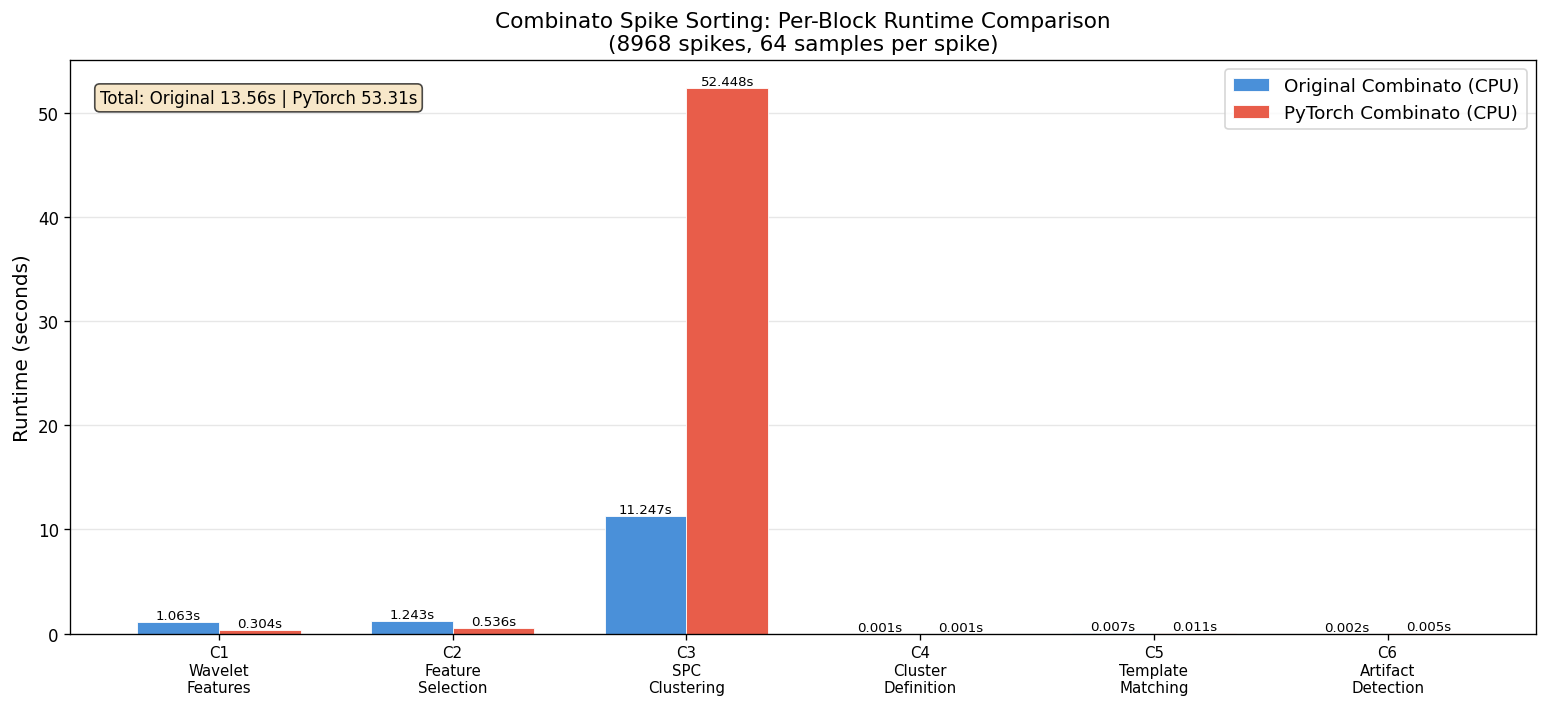


Speedup per block:
  Wavelet        : 3.49x
  Feature Sel    : 2.32x
  SPC            : 0.21x
  Cluster Def    : 0.36x
  Template Match : 0.63x
  Artifact Det   : 0.38x


In [10]:
stages = ['C1_wavelet', 'C2_features', 'C3_spc',
          'C4_clusters', 'C5_match', 'C6_artifact']

labels = ['C1\nWavelet\nFeatures', 'C2\nFeature\nSelection', 'C3\nSPC\nClustering',
          'C4\nCluster\nDefinition', 'C5\nTemplate\nMatching', 'C6\nArtifact\nDetection']

orig_vals = [original_timings.get(s, 0) for s in stages]
pt_vals   = [pytorch_sort_timings.get(s, 0) for s in stages]

x = np.arange(len(stages))
w = 0.35

fig, ax = plt.subplots(figsize=(13, 6))

bars1 = ax.bar(x - w/2, orig_vals, w, label='Original Combinato (CPU)',
               color='#4A90D9', edgecolor='white', linewidth=0.5)
bars2 = ax.bar(x + w/2, pt_vals, w, label='PyTorch Combinato (CPU)',
               color='#E85D4A', edgecolor='white', linewidth=0.5)

# Value labels
for bar in bars1:
    h = bar.get_height()
    if h > 0.0005:
        ax.text(bar.get_x() + bar.get_width()/2, h,
                f'{h:.3f}s', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    h = bar.get_height()
    if h > 0.0005:
        ax.text(bar.get_x() + bar.get_width()/2, h,
                f'{h:.3f}s', ha='center', va='bottom', fontsize=8)

ax.set_ylabel('Runtime (seconds)', fontsize=12)
ax.set_title('Combinato Spike Sorting: Per-Block Runtime Comparison\n'
             f'({spikes_np.shape[0]} spikes, {spikes_np.shape[1]} samples per spike)',
             fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=9)
ax.legend(fontsize=11, loc='upper right')
ax.grid(axis='y', alpha=0.3)
ax.set_axisbelow(True)

# Totals
total_orig = sum(orig_vals)
total_pt   = sum(pt_vals)
ax.text(0.02, 0.95,
        f'Total: Original {total_orig:.2f}s | PyTorch {total_pt:.2f}s',
        transform=ax.transAxes, ha='left', va='top', fontsize=10,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='wheat', alpha=0.7))

fig.tight_layout()
plt.savefig('timing_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nSpeedup per block:")
for s, label in zip(stages, ['Wavelet', 'Feature Sel', 'SPC', 'Cluster Def', 'Template Match', 'Artifact Det']):
    o = original_timings.get(s, 0)
    p = pytorch_sort_timings.get(s, 0)
    if p > 0 and o > 0:
        print(f"  {label:<15s}: {o/p:.2f}x")


## 11. Summary

| Aspect | Result |
|--------|--------|
| **Pipeline** | Full Combinato reimplemented in PyTorch (`CombinatoAlgorithm`) |
| **Extraction** | M1 (filter) → M2 (detect) → M3 (extract) → M4 (upsample) → M5 (align) |
| **Sorting** | C1 (wavelet) → C2 (feature select) → C3 (SPC) → C4 (cluster define) → C5 (template match) → C5b (total match) → C6 (artifact detect) |
| **Validation** | All sorting stages match original exactly (stage-by-stage verified) |
| **Interface** | Single `nn.Module` — `model(signal, times)` returns full results |

The PyTorch reimplementation produces **identical sorting results** to the original Combinato when given the same input spikes.
